# Workflow for importing prepared cordex data to DHIS2

Can be for any country or region. The CORDEX_DATA_PATH just has point to prepared data for a country that matches the orgunits in the DHIS2 instance, so that it's possible to spatially aggregate the data. 

In [1]:
import json
import pandas as pd
import geopandas as gpd
import xarray as xr
from dhis2eo.data.cds import cordex
from dhis2_client import DHIS2Client
from dhis2eo.integrations.pandas import dataframe_to_dhis2_json

In [ ]:
# Params
DHIS2_BASE_URL = 'https://climate.im.dhis2.org/climate-projections-42'
DHIS2_USERNAME = 'admin'
DHIS2_PASSWORD = 'district'
DHIS2_ORG_UNIT_LEVEL = 2
CORDEX_DATA_PATH = '../test_outputs/cordex/sierra_leone/cordex_multivar_sierra_leone.nc'

In [59]:
# Connect
client = DHIS2Client(
    base_url=DHIS2_BASE_URL,
    username=DHIS2_USERNAME,
    password=DHIS2_PASSWORD,
)
info = client.get_system_info()

# Check if everything is working.
# You should see your current DHIS2 version info.
print("Current DHIS2 version:", info["version"])

### Get org units GeoJSON from DHIS2
org_units_geojson = client.get_org_units_geojson(level=DHIS2_ORG_UNIT_LEVEL)

# Convert GeoJSON to geopandas
org_units = gpd.read_file(json.dumps(org_units_geojson))
org_units

Current DHIS2 version: 2.42.3.1


,id,code,name,level,parent,parentGraph,groups,geometry
0,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]","POLYGON ((-11.5914 8.4875, -11.5906 8.4769, -1..."
1,fdc6uOvgoji,OU_193190,Bombali,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, J40PpdN4Wkk, GGghZsfu7qV]","POLYGON ((-11.8091 9.2032, -11.8102 9.1944, -1..."
2,lc3eMKXaEfw,OU_197385,Bonthe,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy, GGghZsfu7qV]","MULTIPOLYGON (((-12.5568 7.3832, -12.5574 7.38..."
3,jUb8gELQApl,OU_204856,Kailahun,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, GGghZsfu7qV, nlX2VoouN63]","POLYGON ((-10.7972 7.5866, -10.8002 7.5878, -1..."
4,PMa2VCrupOd,OU_211212,Kambia,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, GGghZsfu7qV, b0EsAxm8Nge, nlX2Vo...","MULTIPOLYGON (((-13.1349 8.8471, -13.1343 8.84..."
5,kJq2mPyFEHo,OU_222616,Kenema,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL]","POLYGON ((-11.3596 8.5317, -11.3513 8.5234, -1..."
6,qhqAxPSTUXp,OU_226213,Koinadugu,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, J40PpdN4Wkk]","POLYGON ((-10.585 9.0434, -10.5877 9.0432, -10..."
7,Vth0fbpFcsO,OU_233310,Kono,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, J40PpdN4Wkk]","POLYGON ((-10.585 9.0434, -10.5848 9.0432, -10..."
8,jmIPBj66vD6,OU_246990,Moyamba,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, jqBqIXoXpfy]","MULTIPOLYGON (((-12.6351 7.6613, -12.6346 7.66..."
9,TEQlaapDQoK,OU_254945,Port Loko,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, b0EsAxm8Nge]","MULTIPOLYGON (((-13.119 8.4718, -13.1174 8.470..."


## Run from saved output

In [ ]:
# open from disk
ds = xr.open_dataset(CORDEX_DATA_PATH)
ds

<xarray.Dataset> Size: 73MB
Dimensions:       (scenario: 1, ensemble: 7, time: 900, rlat: 16, rlon: 15)
Coordinates:
  * scenario      (scenario) <U5 20B 'rcp85'
  * ensemble      (ensemble) <U47 1kB 'CCCma-CanRCM4__CCCma-CanESM2__r1i1p1' ...
  * time          (time) datetime64[ns] 7kB 2021-01-01 2021-02-01 ... 2095-12-01
  * rlat          (rlat) float64 128B 6.71 6.93 7.15 7.37 ... 9.57 9.79 10.01
  * rlon          (rlon) float64 120B -13.31 -13.09 -12.87 ... -10.45 -10.23
    rotated_pole  |S1 1B ...
    lon           (rlat, rlon) float64 2kB ...
    lat           (rlat, rlon) float64 2kB ...
    height        float64 8B ...
Data variables:
    pr_sum        (scenario, ensemble, time, rlat, rlon) float64 12MB ...
    tas_mean      (scenario, ensemble, time, rlat, rlon) float64 12MB ...
    tasmin_mean   (scenario, ensemble, time, rlat, rlon) float64 12MB ...
    tasmin_min    (scenario, ensemble, time, rlat, rlon) float64 12MB ...
    tasmax_mean   (scenario, ensemble, time, rlat, rlon) float64 12MB ...
    tasmax_max    (scenario, ensemble, time, rlat, rlon) float64 12MB ...

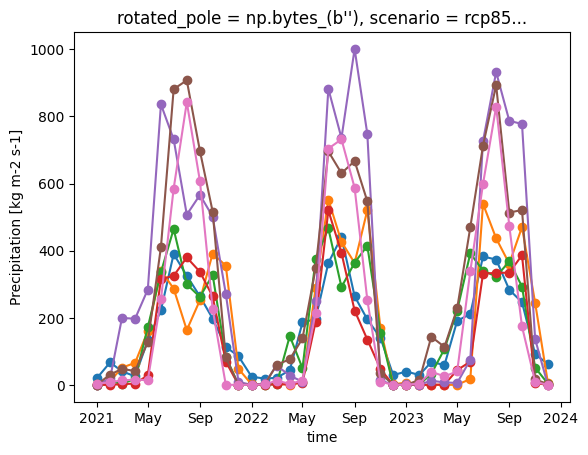

In [21]:
# quick sanity timeseries test for entire country
country = ds.mean(dim=["rlat","rlon"])
country['pr_sum'].sel(time=slice(None, '2023')).plot(x="time", hue='ensemble', marker="o", linestyle="-", add_legend=False)

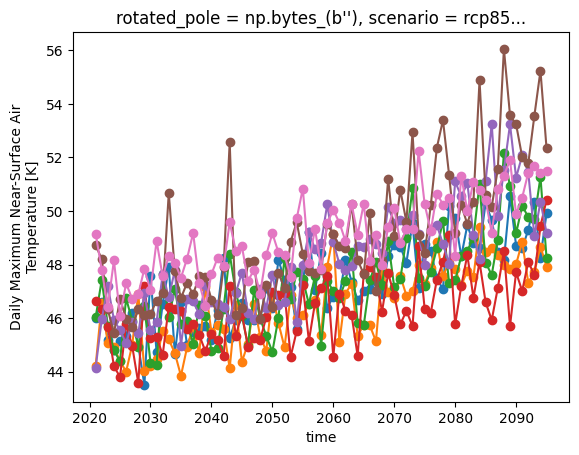

In [ ]:
# quick sanity timeseries test for entire country (max pixel), yearly max temp
country = ds.max(dim=["rlat","rlon"])
country_year = country['tasmax_max'].resample(time="YS", skipna=True).max(dim='time')
country_year.plot(x="time", hue='ensemble', marker="o", linestyle="-", add_legend=False)

In [28]:
# for each variable compute ensemble stats
ens_vars = {}
for var in 'pr_sum tas_mean tasmin_mean tasmin_min tasmax_mean tasmax_max'.split():
    print(var)
    for stat in 'min mean max'.split():
        ens_vars[f"{var}_ens_{stat}"] = getattr(ds[var], stat)(dim="ensemble")

# create new ensemble ds
ds_ens = xr.Dataset(ens_vars)
ds_ens

pr_sum
tas_mean
tasmin_mean
tasmin_min
tasmax_mean
tasmax_max


<xarray.Dataset> Size: 31MB
Dimensions:               (rlon: 15, rlat: 16, scenario: 1, time: 900)
Coordinates:
  * rlon                  (rlon) float64 120B -13.31 -13.09 ... -10.45 -10.23
  * rlat                  (rlat) float64 128B 6.71 6.93 7.15 ... 9.57 9.79 10.01
  * scenario              (scenario) <U5 20B 'rcp85'
  * time                  (time) datetime64[ns] 7kB 2021-01-01 ... 2095-12-01
    rotated_pole          |S1 1B b''
    lon                   (rlat, rlon) float64 2kB -13.31 -13.09 ... -10.23
    lat                   (rlat, rlon) float64 2kB 6.71 6.71 ... 10.01 10.01
    height                float64 8B 2.0
Data variables: (12/18)
    pr_sum_ens_min        (scenario, time, rlat, rlon) float64 2MB 0.0 ... 0.0
    pr_sum_ens_mean       (scenario, time, rlat, rlon) float64 2MB 5.3 ... 0....
    pr_sum_ens_max        (scenario, time, rlat, rlon) float64 2MB 20.63 ... ...
    tas_mean_ens_min      (scenario, time, rlat, rlon) float64 2MB 26.87 ... ...
    tas_mean_ens_mean     (scenario, time, rlat, rlon) float64 2MB 28.7 ... 2...
    tas_mean_ens_max      (scenario, time, rlat, rlon) float64 2MB 29.85 ... ...
    ...                    ...
    tasmax_mean_ens_min   (scenario, time, rlat, rlon) float64 2MB 27.26 ... ...
    tasmax_mean_ens_mean  (scenario, time, rlat, rlon) float64 2MB 29.08 ... ...
    tasmax_mean_ens_max   (scenario, time, rlat, rlon) float64 2MB 30.33 ... ...
    tasmax_max_ens_min    (scenario, time, rlat, rlon) float64 2MB 27.91 ... ...
    tasmax_max_ens_mean   (scenario, time, rlat, rlon) float64 2MB 29.88 ... ...
    tasmax_max_ens_max    (scenario, time, rlat, rlon) float64 2MB 31.67 ... ...

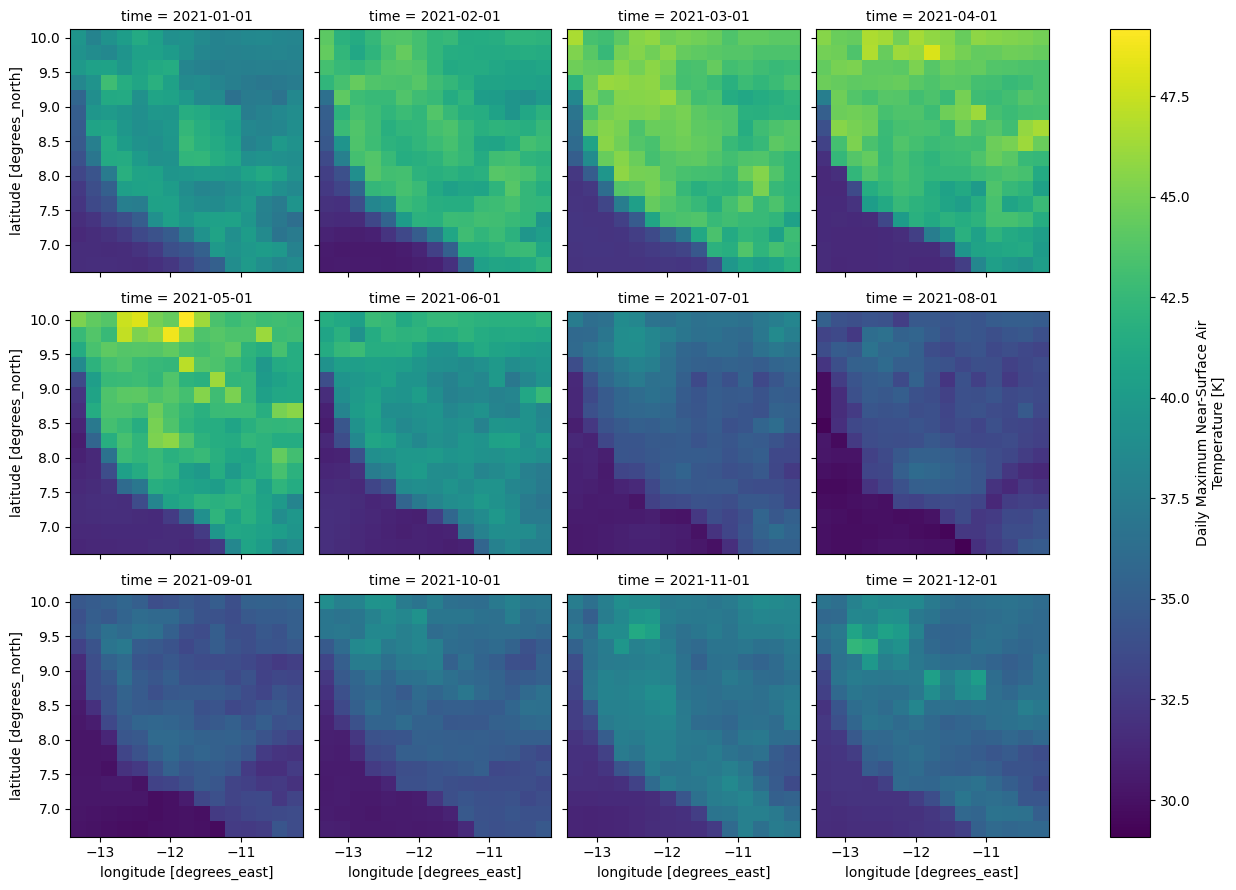

In [44]:
# quick sanity test of ensemble stats on a map
import matplotlib.pyplot as plt
grid = ds['tasmax_max'].isel(time=slice(12)).max(dim='ensemble')
grid.plot(x='lon', y='lat', col='time', col_wrap=4)
xmin,ymin,xmax,ymax = org_units.total_bounds

In [47]:
# aggregate with partial overlaps
# TOOD: switch to different library and method
import xagg
ds_renamed = ds_ens.drop_vars(['lon', 'lat']).rename({'rlon':'lon', 'rlat':'lat'})
print(ds_renamed)
weightmap = xagg.pixel_overlaps(ds_renamed, org_units)
aggregated = xagg.aggregate(ds_renamed, weightmap)
ds_org_units = aggregated.to_dataset() #[['tas_mean_ens_mean', 'tas_mean_ens_min', 'tas_mean_ens_max', 'id']]
ds_org_units

<xarray.Dataset> Size: 31MB
Dimensions:               (lon: 15, lat: 16, scenario: 1, time: 900)
Coordinates:
  * lon                   (lon) float64 120B -13.31 -13.09 ... -10.45 -10.23
  * lat                   (lat) float64 128B 6.71 6.93 7.15 ... 9.57 9.79 10.01
  * scenario              (scenario) <U5 20B 'rcp85'
  * time                  (time) datetime64[ns] 7kB 2021-01-01 ... 2095-12-01
    rotated_pole          |S1 1B b''
    height                float64 8B 2.0
Data variables: (12/18)
    pr_sum_ens_min        (scenario, time, lat, lon) float64 2MB 0.0 0.0 ... 0.0
    pr_sum_ens_mean       (scenario, time, lat, lon) float64 2MB 5.3 ... 0.2109
    pr_sum_ens_max        (scenario, time, lat, lon) float64 2MB 20.63 ... 1.36
    tas_mean_ens_min      (scenario, time, lat, lon) float64 2MB 26.87 ... 25.63
    tas_mean_ens_mean     (scenario, time, lat, lon) float64 2MB 28.7 ... 27.83
    tas_mean_ens_max      (scenario, time, lat, lon) float64 2MB 29.85 ... 29.74
    ...          

<xarray.Dataset> Size: 2MB
Dimensions:               (poly_idx: 13, scenario: 1, time: 900)
Coordinates:
  * poly_idx              (poly_idx) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * scenario              (scenario) <U5 20B 'rcp85'
  * time                  (time) datetime64[ns] 7kB 2021-01-01 ... 2095-12-01
Data variables: (12/25)
    id                    (poly_idx) object 104B 'O6uvpzGd5pu' ... 'at6UHUQatSo'
    code                  (poly_idx) object 104B 'OU_264' ... 'OU_278310'
    name                  (poly_idx) object 104B 'Bo' ... 'Western Area'
    level                 (poly_idx) object 104B '2' '2' '2' '2' ... '2' '2' '2'
    parent                (poly_idx) object 104B 'ImspTQPwCqd' ... 'ImspTQPwCqd'
    parentGraph           (poly_idx) object 104B 'ImspTQPwCqd' ... 'ImspTQPwCqd'
    ...                    ...
    tasmax_mean_ens_min   (poly_idx, scenario, time) float64 94kB 30.28 ... 3...
    tasmax_mean_ens_mean  (poly_idx, scenario, time) float64 94kB 34.14 ... 3...
    tasmax_mean_ens_max   (poly_idx, scenario, time) float64 94kB 37.64 ... 3...
    tasmax_max_ens_min    (poly_idx, scenario, time) float64 94kB 32.28 ... 3...
    tasmax_max_ens_mean   (poly_idx, scenario, time) float64 94kB 36.21 ... 3...
    tasmax_max_ens_max    (poly_idx, scenario, time) float64 94kB 40.11 ... 3...

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Poly #0: O6uvpzGd5pu; OU_264; Bo; 2; ImspTQPwCqd'}>)

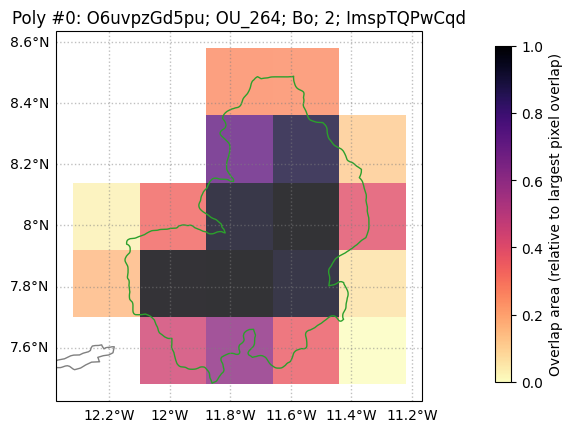

In [48]:
# diagnostic visualization of pixel overlaps
weightmap.diag_fig(0, ds_renamed)

In [49]:
dataframe = ds_org_units.to_dataframe().reset_index()
dataframe

,poly_idx,scenario,time,id,code,name,level,parent,parentGraph,groups,...,tasmin_mean_ens_max,tasmin_min_ens_min,tasmin_min_ens_mean,tasmin_min_ens_max,tasmax_mean_ens_min,tasmax_mean_ens_mean,tasmax_mean_ens_max,tasmax_max_ens_min,tasmax_max_ens_mean,tasmax_max_ens_max
0,0,rcp85,2021-01-01,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]",...,22.417991,14.284519,17.517399,19.318021,30.276291,34.144151,37.636827,32.280955,36.205897,40.105280
1,0,rcp85,2021-02-01,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]",...,25.733452,15.094130,19.491877,23.174381,32.664065,35.900550,39.506207,35.255215,38.553435,41.927278
2,0,rcp85,2021-03-01,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]",...,27.081764,20.742875,23.314471,25.455131,33.797785,37.035446,40.305269,36.563336,40.005103,43.386138
3,0,rcp85,2021-04-01,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]",...,27.015838,21.379062,24.187257,26.044185,32.880926,36.279602,39.804228,35.414175,39.334485,42.074780
4,0,rcp85,2021-05-01,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]",...,26.221144,21.119000,23.689955,24.972389,30.302857,33.197423,38.211850,35.667532,38.150785,41.634768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11695,12,rcp85,2095-08-01,at6UHUQatSo,OU_278310,Western Area,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, b0EsAxm8Nge]",...,30.520651,25.672695,27.181028,29.866606,29.831672,30.545259,31.986524,31.271067,32.195694,33.505526
11696,12,rcp85,2095-09-01,at6UHUQatSo,OU_278310,Western Area,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, b0EsAxm8Nge]",...,30.845501,25.103848,27.333060,30.072824,30.178896,31.076789,32.479351,31.879328,32.971293,34.179422
11697,12,rcp85,2095-10-01,at6UHUQatSo,OU_278310,Western Area,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, b0EsAxm8Nge]",...,31.130039,26.034622,27.847450,30.182176,31.017155,32.494140,33.578434,32.321876,34.038199,35.906168
11698,12,rcp85,2095-11-01,at6UHUQatSo,OU_278310,Western Area,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, b0EsAxm8Nge]",...,31.309717,20.492506,26.193509,30.053103,32.372475,33.917001,35.979705,33.756296,36.008679,38.528458


## Create metadata

In [66]:
data_elements = []
for ens_stat in 'min mean max'.split():
    data_elements += [
        {
            "name": f"Precipitation (CORDEX RCP 8.5, Ensemble {ens_stat.title()})",
            "shortName": f"Precip - RCP85 Ens {ens_stat.title()}",
            "code": f"PRECIP_ENS_{ens_stat.upper()}_RCP85_CORDEX",
            "valueType": "NUMBER",
            "aggregationType": "SUM",
            "domainType": "AGGREGATE"
        },
        {
            "name": f"2m Temperature, Mean (CORDEX RCP 8.5, Ensemble {ens_stat.title()})",
            "shortName": f"Temp Mean - RCP85 Ens {ens_stat.title()}",
            "code": f"TEMP_MEAN_DAILY_MEAN_ENS_{ens_stat.upper()}_RCP85_CORDEX",
            "valueType": "NUMBER",
            "aggregationType": "AVERAGE",
            "domainType": "AGGREGATE"
        },
        {
            "name": f"2m Temperature, Highest Daily (CORDEX RCP 8.5, Ensemble {ens_stat.title()})",
            "shortName": f"Temp Highest - RCP85 Ens {ens_stat.title()}",
            "code": f"TEMP_MAX_DAILY_MAX_ENS_{ens_stat.upper()}_RCP85_CORDEX",
            "valueType": "NUMBER",
            "aggregationType": "MAX",
            "domainType": "AGGREGATE"
        },
        {
            "name": f"2m Temperature, Lowest Daily (CORDEX RCP 8.5, Ensemble {ens_stat.title()})",
            "shortName": f"Temp Lowest - RCP85 Ens {ens_stat.title()}",
            "code": f"TEMP_MIN_DAILY_MIN_ENS_{ens_stat.upper()}_RCP85_CORDEX",
            "valueType": "NUMBER",
            "aggregationType": "MIN",
            "domainType": "AGGREGATE"
        },
        {
            "name": f"2m Temperature, Average Daily High (CORDEX RCP 8.5, Ensemble {ens_stat.title()})",
            "shortName": f"Temp Avg High - RCP85 Ens {ens_stat.title()}",
            "code": f"TEMP_MEAN_DAILY_MAX_ENS_{ens_stat.upper()}_RCP85_CORDEX",
            "valueType": "NUMBER",
            "aggregationType": "AVERAGE",
            "domainType": "AGGREGATE"
        },
        {
            "name": f"2m Temperature, Average Daily Low (CORDEX RCP 8.5, Ensemble {ens_stat.title()})",
            "shortName": f"Temp Avg Low - RCP85 Ens {ens_stat.title()}",
            "code": f"TEMP_MEAN_DAILY_MIN_ENS_{ens_stat.upper()}_RCP85_CORDEX",
            "valueType": "NUMBER",
            "aggregationType": "AVERAGE",
            "domainType": "AGGREGATE"
        },
    ]
data_elements

[{'name': 'Precipitation (CORDEX RCP 8.5, Ensemble Min)',
  'shortName': 'Precip - RCP85 Ens Min',
  'code': 'PRECIP_ENS_MIN_RCP85_CORDEX',
  'valueType': 'NUMBER',
  'aggregationType': 'SUM',
  'domainType': 'AGGREGATE'},
 {'name': '2m Temperature, Mean (CORDEX RCP 8.5, Ensemble Min)',
  'shortName': 'Temp Mean - RCP85 Ens Min',
  'code': 'TEMP_MEAN_DAILY_MEAN_ENS_MIN_RCP85_CORDEX',
  'valueType': 'NUMBER',
  'aggregationType': 'AVERAGE',
  'domainType': 'AGGREGATE'},
 {'name': '2m Temperature, Highest Daily (CORDEX RCP 8.5, Ensemble Min)',
  'shortName': 'Temp Highest - RCP85 Ens Min',
  'code': 'TEMP_MAX_DAILY_MAX_ENS_MIN_RCP85_CORDEX',
  'valueType': 'NUMBER',
  'aggregationType': 'MAX',
  'domainType': 'AGGREGATE'},
 {'name': '2m Temperature, Lowest Daily (CORDEX RCP 8.5, Ensemble Min)',
  'shortName': 'Temp Lowest - RCP85 Ens Min',
  'code': 'TEMP_MIN_DAILY_MIN_ENS_MIN_RCP85_CORDEX',
  'valueType': 'NUMBER',
  'aggregationType': 'MIN',
  'domainType': 'AGGREGATE'},
 {'name': '2m 

In [71]:
for de in data_elements:
    code  = de['code']
    if not list(client.get_data_elements(filter=[f"code:eq:{code}"])):
        print(de)
        de_created = client.create_data_element(de)
        print(f"Data element creation status: {de_created['status']} and UID: {de_created['response']['uid']}")

{'name': 'Precipitation (CORDEX RCP 8.5, Ensemble Min)', 'shortName': 'Precip - RCP85 Ens Min', 'code': 'PRECIP_ENS_MIN_RCP85_CORDEX', 'valueType': 'NUMBER', 'aggregationType': 'SUM', 'domainType': 'AGGREGATE'}
Data element creation status: OK and UID: nTfufohlFxU
{'name': 'Precipitation (CORDEX RCP 8.5, Ensemble Mean)', 'shortName': 'Precip - RCP85 Ens Mean', 'code': 'PRECIP_ENS_MEAN_RCP85_CORDEX', 'valueType': 'NUMBER', 'aggregationType': 'SUM', 'domainType': 'AGGREGATE'}
Data element creation status: OK and UID: KyViqjek2LY
{'name': 'Precipitation (CORDEX RCP 8.5, Ensemble Max)', 'shortName': 'Precip - RCP85 Ens Max', 'code': 'PRECIP_ENS_MAX_RCP85_CORDEX', 'valueType': 'NUMBER', 'aggregationType': 'SUM', 'domainType': 'AGGREGATE'}
Data element creation status: OK and UID: Qr9CQf7u1m7


## Import to DHIS2

In [73]:
# map vars to DHIS2 data element codes
var_codes = {}
for ens_stat in 'min mean max'.split():
    var_codes.update({
        f'pr_sum_ens_{ens_stat}':          f'PRECIP_ENS_{ens_stat.upper()}_RCP85_CORDEX',
        f'tas_mean_ens_{ens_stat}':        f'TEMP_MEAN_DAILY_MEAN_ENS_{ens_stat.upper()}_RCP85_CORDEX',
        f'tasmin_mean_ens_{ens_stat}':     f'TEMP_MEAN_DAILY_MIN_ENS_{ens_stat.upper()}_RCP85_CORDEX',
        f'tasmax_mean_ens_{ens_stat}':     f'TEMP_MEAN_DAILY_MAX_ENS_{ens_stat.upper()}_RCP85_CORDEX',
        f'tasmin_min_ens_{ens_stat}':      f'TEMP_MIN_DAILY_MIN_ENS_{ens_stat.upper()}_RCP85_CORDEX',
        f'tasmax_max_ens_{ens_stat}':      f'TEMP_MAX_DAILY_MAX_ENS_{ens_stat.upper()}_RCP85_CORDEX',
    })
var_codes

{'pr_sum_ens_min': 'PRECIP_ENS_MIN_RCP85_CORDEX',
 'tas_mean_ens_min': 'TEMP_MEAN_DAILY_MEAN_ENS_MIN_RCP85_CORDEX',
 'tasmin_mean_ens_min': 'TEMP_MEAN_DAILY_MIN_ENS_MIN_RCP85_CORDEX',
 'tasmax_mean_ens_min': 'TEMP_MEAN_DAILY_MAX_ENS_MIN_RCP85_CORDEX',
 'tasmin_min_ens_min': 'TEMP_MIN_DAILY_MIN_ENS_MIN_RCP85_CORDEX',
 'tasmax_max_ens_min': 'TEMP_MAX_DAILY_MAX_ENS_MIN_RCP85_CORDEX',
 'pr_sum_ens_mean': 'PRECIP_ENS_MEAN_RCP85_CORDEX',
 'tas_mean_ens_mean': 'TEMP_MEAN_DAILY_MEAN_ENS_MEAN_RCP85_CORDEX',
 'tasmin_mean_ens_mean': 'TEMP_MEAN_DAILY_MIN_ENS_MEAN_RCP85_CORDEX',
 'tasmax_mean_ens_mean': 'TEMP_MEAN_DAILY_MAX_ENS_MEAN_RCP85_CORDEX',
 'tasmin_min_ens_mean': 'TEMP_MIN_DAILY_MIN_ENS_MEAN_RCP85_CORDEX',
 'tasmax_max_ens_mean': 'TEMP_MAX_DAILY_MAX_ENS_MEAN_RCP85_CORDEX',
 'pr_sum_ens_max': 'PRECIP_ENS_MAX_RCP85_CORDEX',
 'tas_mean_ens_max': 'TEMP_MEAN_DAILY_MEAN_ENS_MAX_RCP85_CORDEX',
 'tasmin_mean_ens_max': 'TEMP_MEAN_DAILY_MIN_ENS_MAX_RCP85_CORDEX',
 'tasmax_mean_ens_max': 'TEMP_MEAN_D

In [74]:
# dryrun or not
DRY_RUN = 'false'

In [ ]:
# run the imports for each
for var,code in var_codes.items():
    print(var, code)
    payload = dataframe_to_dhis2_json(
        df = dataframe.query("scenario == 'rcp85'"),
        org_unit_col = 'id',
        period_col = 'time',
        value_col = var,
        data_element_id = code,
    )
    import_params = {'dryRun': DRY_RUN, 'dataElementIdScheme': 'CODE', 'importStrategy': 'CREATE_AND_UPDATE'}
    res = client.post("/api/dataValueSets", json=payload, params=import_params)
    print(res['response']['importCount'])

pr_sum_ens_min PRECIP_ENS_MIN_RCP85_CORDEX
{'imported': 11081, 'updated': 0, 'ignored': 0, 'deleted': 0}
pr_sum_ens_mean PRECIP_ENS_MEAN_RCP85_CORDEX
{'imported': 11700, 'updated': 0, 'ignored': 0, 'deleted': 0}
pr_sum_ens_max PRECIP_ENS_MAX_RCP85_CORDEX
{'imported': 11700, 'updated': 0, 'ignored': 0, 'deleted': 0}
